# АНАЛИЗ ИСХОДНОГО ДАТАСЕТА

In [1]:
import sys
print(sys.executable)
import os
print("Текущая директория:", os.getcwd())

/bin/python3
Текущая директория: /home/ubuntu/calories_dish


In [4]:
import torch
# Определяем устройство (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

# Если используется GPU, показываем информацию
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Память GPU: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Используется устройство: cuda
GPU: Tesla T4
Память GPU: 14.6 GB


## БЛЮДА В dish.csv

=== БЛЮДА ===
Размер: (3262, 5)
Количество блюд: 3262

Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB
None

Пропущенные значения:
dish_id           0
total_calories    0
total_mass        0
ingredients       0
split             0
dtype: int64

Статистика числовых признаков:
       total_calories   total_mass
count     3262.000000  3262.000000
mean       255.012738   214.980074
std        219.637570   161.497428
min          0.000000     1.000000
25%         80.114996    92.000000
50%        209.110062   177.000000
75%        375.122963   305.0

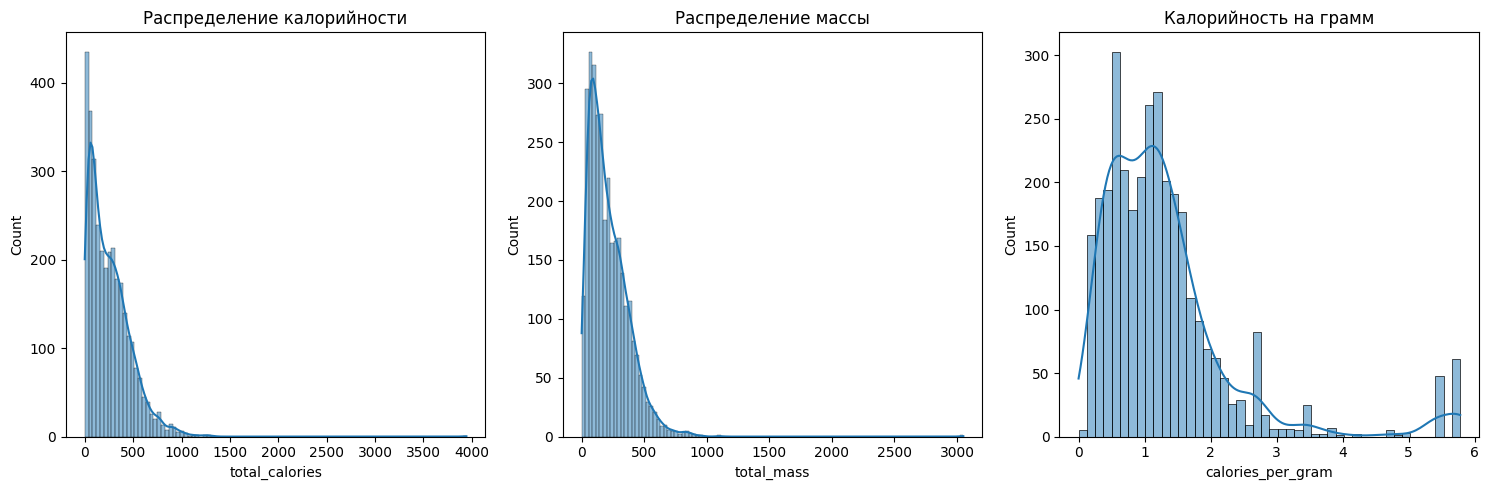

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
dish_df = pd.read_csv('data/dish.csv')
ingredients_df = pd.read_csv('data/ingredients.csv')

# Базовая информация
print("=== БЛЮДА ===")
print(f"Размер: {dish_df.shape}")
print(f"Количество блюд: {len(dish_df)}")
print("\nИнформация о столбцах:")
print(dish_df.info())
print("\nПропущенные значения:")
print(dish_df.isnull().sum())

# Статистика по числовым признакам
print("\nСтатистика числовых признаков:")
print(dish_df[['total_calories', 'total_mass']].describe())

# Анализ распределения целевой переменной
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(dish_df['total_calories'], kde=True)
plt.title('Распределение калорийности')

plt.subplot(1, 3, 2)
sns.histplot(dish_df['total_mass'], kde=True)
plt.title('Распределение массы')

plt.subplot(1, 3, 3)
# Калорийность на грамм
dish_df['calories_per_gram'] = dish_df['total_calories'] / dish_df['total_mass']
sns.histplot(dish_df['calories_per_gram'], kde=True)
plt.title('Калорийность на грамм')

plt.tight_layout()
plt.show()

## ИНГРЕДИЕНТЫ В ingredients.csv

In [7]:
print("\n=== ИНГРЕДИЕНТЫ ===")
print(f"Уникальных ингредиентов: {len(ingredients_df)}")
print(f"Примеры ингредиентов:")
print(ingredients_df.head(3))


=== ИНГРЕДИЕНТЫ ===
Уникальных ингредиентов: 555
Примеры ингредиентов:
   id            ingr
0   1  cottage cheese
1   2    strawberries
2   3    garden salad


## РАСПРЕДЕЛЕНИЕ train/test

In [8]:
# Распределение по сплитам
split_counts = dish_df['split'].value_counts()
print(f"\nРаспределение по сплитам:\n{split_counts}")


Распределение по сплитам:
split
train    2755
test      507
Name: count, dtype: int64


## ФОТО БЛЮД

In [9]:
import os
from PIL import Image
import cv2

# Проверка наличия изображений
image_dir = 'data/images'
dish_ids_with_images = set([d for d in os.listdir(image_dir) if os.path.isdir(os.path.join(image_dir, d))])
dish_ids_in_csv = set(dish_df['dish_id'].astype(str))

print(f"\n=== Анализ изображений ===")
print(f"Блюд с изображениями: {len(dish_ids_with_images)}")
print(f"Блюд в CSV: {len(dish_ids_in_csv)}")
#print(f"Пересечение: {len(dish_ids_with_images & dish_ids_in_csv)}")
print(f"Блюда без изображений: {len(dish_ids_in_csv - dish_ids_with_images)}")
print(f"Изображения без ингредиентов: {len(dish_ids_with_images-dish_ids_in_csv)}")

# Анализ размеров и форматов изображений
image_stats = []
for dish_id in list(dish_ids_with_images)[:100]:  # Проверим первые 100
    img_path = os.path.join(image_dir, dish_id, 'rgb.png')
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            image_stats.append({'dish_id': dish_id, 'width': width, 'height': height, 'mode': img.mode})
    except:
        continue

image_stats_df = pd.DataFrame(image_stats)
print(f"\nСтатистика изображений:")
print(image_stats_df[['width', 'height']].describe())


=== Анализ изображений ===
Блюд с изображениями: 3490
Блюд в CSV: 3262
Блюда без изображений: 0
Изображения без ингредиентов: 228

Статистика изображений:
       width  height
count  100.0   100.0
mean   640.0   480.0
std      0.0     0.0
min    640.0   480.0
25%    640.0   480.0
50%    640.0   480.0
75%    640.0   480.0
max    640.0   480.0


## ВЫВОДЫ И РЕЗУЛЬТАТ АНАЛИЗА ДАТАСЕТА
ДАТАСЕТ в целом - необходимо учесть, что у 228 фото нет текстового описания ингредиентов. Для нашей задачи эти примеры не подходят. А также почистить те примеры, где калорийность и/или масса блюда слишком мала или слишком завышена, что скорее говорит об ошибке при составлении данных.
Изображения - для обучения начнем с минимальных изменений и аугментаций: Resize((224, 224)), RandomHorizontalFlip(0.3), RandomRotation(10), ColorJitter(brightness=0.2, contrast=0.2) + ToTensor() и Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]).

Для предсказания калорий построим и дообучим мультимодальную модель. Модальности: текст ингредиентов, изображения блюд, multi-hot бинарная таблица с ингредиентами, масса.Целевой признак - калории  Используем две предобученных модели: TEXT_MODEL_NAME = "bert-base-uncased", IMAGE_MODEL_NAME = "tf_efficientnet_b0".

Будем считать модель приемлемой, если МАЕ <50, что означает, что модель в среднем ошибается не более чем на 50 ккал на одно блюдо.

# ОСНОВНОЙ ПАЙПЛАЙН ОБУЧЕНИЯ И ВАЛИДАЦИИ МОДЕЛИ

Оригинальный датасет: 3262 примеров
После очистки: 3200 примеров
✅ Создан словарь с 555 ингредиентами
✅ Создан словарь с 555 ингредиентами
Примеров в Train: 2697
Примеров в Test: 503
Стартую обучение ...
Epoch 1/30:
  Train - MAE: 108.39, F1: 0.5783, R²: 0.4648
  Test  - MAE: 67.81, F1: 0.7672, R²: 0.6973
Epoch 2/30:
  Train - MAE: 65.37, F1: 0.7332, R²: 0.7724
  Test  - MAE: 79.81, F1: 0.6658, R²: 0.7000
Epoch 3/30:
  Train - MAE: 57.03, F1: 0.7755, R²: 0.8184
  Test  - MAE: 47.59, F1: 0.8095, R²: 0.8792
Epoch 4/30:
  Train - MAE: 57.36, F1: 0.7609, R²: 0.8266
  Test  - MAE: 60.58, F1: 0.7425, R²: 0.8085
Epoch 5/30:
  Train - MAE: 55.92, F1: 0.7657, R²: 0.8400
  Test  - MAE: 64.13, F1: 0.7611, R²: 0.7606
Epoch 6/30:
  Train - MAE: 54.61, F1: 0.7741, R²: 0.8270
  Test  - MAE: 53.82, F1: 0.8010, R²: 0.8209
Epoch 7/30:
  Train - MAE: 49.28, F1: 0.7971, R²: 0.8602
  Test  - MAE: 46.11, F1: 0.8095, R²: 0.8811
Epoch 8/30:
  Train - MAE: 48.56, F1: 0.8082, R²: 0.8637
  Test  - MAE: 58.82, F1

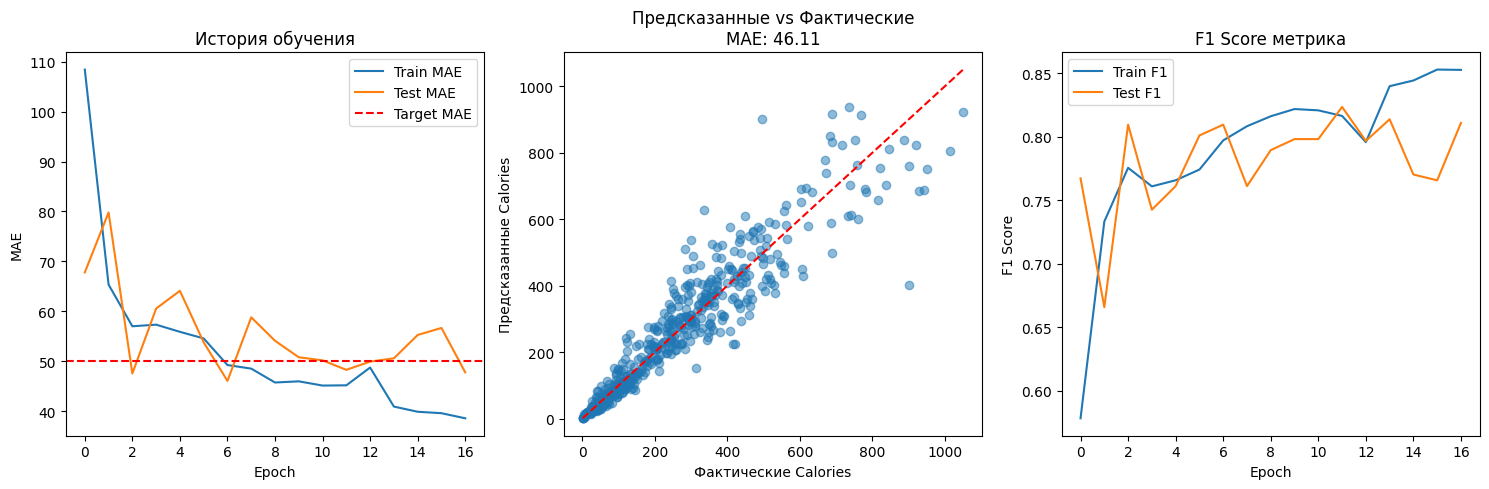

In [14]:
import torch
import torch.nn as nn
import sys
import os
from tqdm import tqdm 

# путь к папке scripts
sys.path.append(os.path.join(os.getcwd(), 'scripts'))
from utils import seed_everything, train

class Config:
    # для воспроизводимости
    SEED = 42

    # модели
    TEXT_MODEL_NAME = "bert-base-uncased"
    IMAGE_MODEL_NAME = "tf_efficientnet_b0"

    # слои для разморозки
    TEXT_MODEL_UNFREEZE = "encoder.layer.11|pooler"
    IMAGE_MODEL_UNFREEZE = "blocks.6|conv_head|bn2"

    # гиперпараметры
    BATCH_SIZE = 32
    TEXT_LR = 3e-5
    IMAGE_LR = 1e-4
    CLASSIFIER_LR = 1e-3
    EPOCHS = 30
    DROPOUT = 0.3
    HIDDEN_DIM = 256
    PATIENCE = 10
    GRAD_CLIP = 1.0

    # пути
    DATA_PATH = "data"
    IMAGE_DIR = "data/images"
    SAVE_PATH = "best_model.pth"

# запуск обучения
device = "cuda" if torch.cuda.is_available() else "cpu"
cfg = Config()
model, history, final_mae, final_f1 = train(cfg, device)

# ВАЛИДАЦИЯ КАЧЕСТВА И ВЫВОДЫ

Загрузка и оценка лучшей модели...
Оригинальный датасет: 3262 примеров
После очистки: 3200 примеров
✅ Создан словарь с 555 ингредиентами
✅ Создан словарь с 555 ингредиентами
✅ Модель успешно загружена

ФИНАЛЬНЫЕ МЕТРИКИ МОДЕЛИ
📊 Test MAE:  46.11 ккал
📊 Test RMSE: 73.01 ккал
📊 Test R²:   0.8811
📊 Test F1:   0.8095
🎯 ✅ Модель соответствует целевому показателю (MAE < 50)


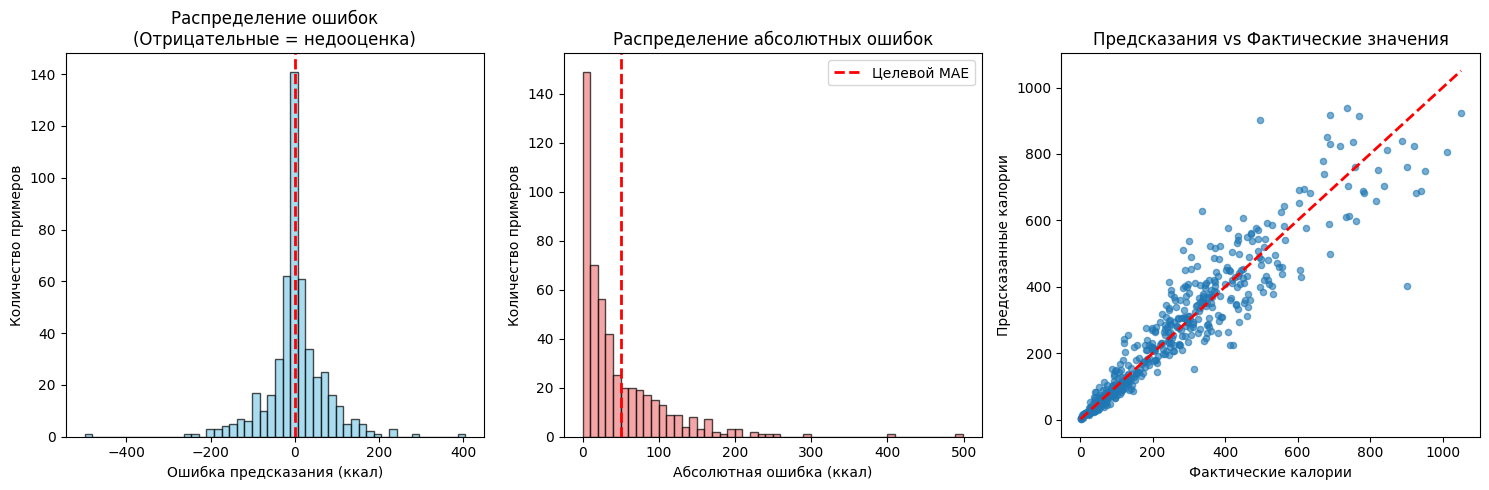


СТАТИСТИКА ОШИБОК
📈 Средняя ошибка: 2.51 ккал
📈 Медианная ошибка: 0.21 ккал
📈 Стандартное отклонение: 72.97 ккал
📊 % примеров с ошибкой < 50 ккал: 68.0%
📊 % примеров с ошибкой < 100 ккал: 86.1%

🍽️  ТОП-5 БЛЮД С НАИБОЛЬШЕЙ ОШИБКОЙ ПРЕДСКАЗАНИЯ

🔴 #1 | Ошибка: 499.3 ккал
   ID блюда: dish_1565811139
   🎯 Фактические калории: 902 ккал
   🤖 Предсказанные калории: 403 ккал
   ⚖️  Масса блюда: 416 г
   🥗 Ингредиенты: carrot, goat cheese, olive oil, broccoli, spinach (raw), chicken


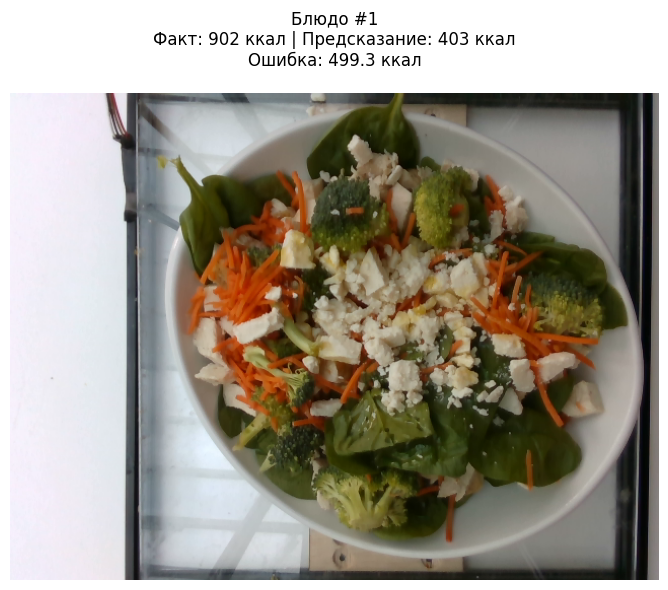


🔴 #2 | Ошибка: 404.4 ккал
   ID блюда: dish_1558722125
   🎯 Фактические калории: 497 ккал
   🤖 Предсказанные калории: 902 ккал
   ⚖️  Масса блюда: 86 г
   🥗 Ингредиенты: almonds


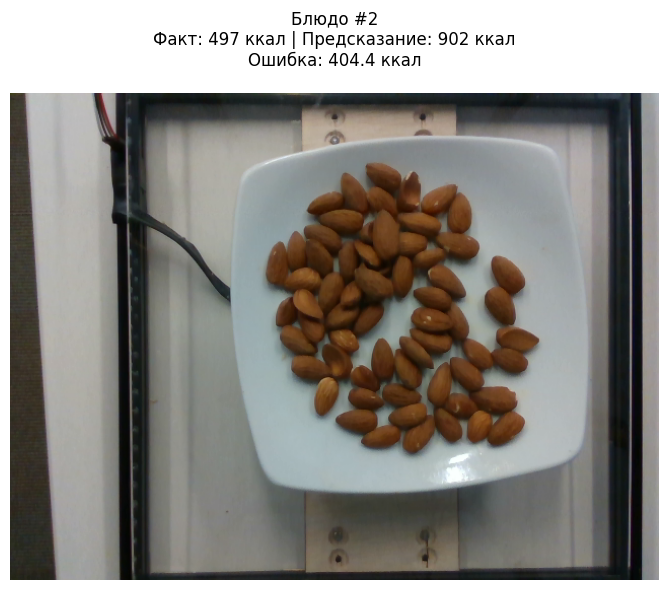


🔴 #3 | Ошибка: 292.8 ккал
   ID блюда: dish_1558376874
   🎯 Фактические калории: 335 ккал
   🤖 Предсказанные калории: 628 ккал
   ⚖️  Масса блюда: 58 г
   🥗 Ингредиенты: almonds


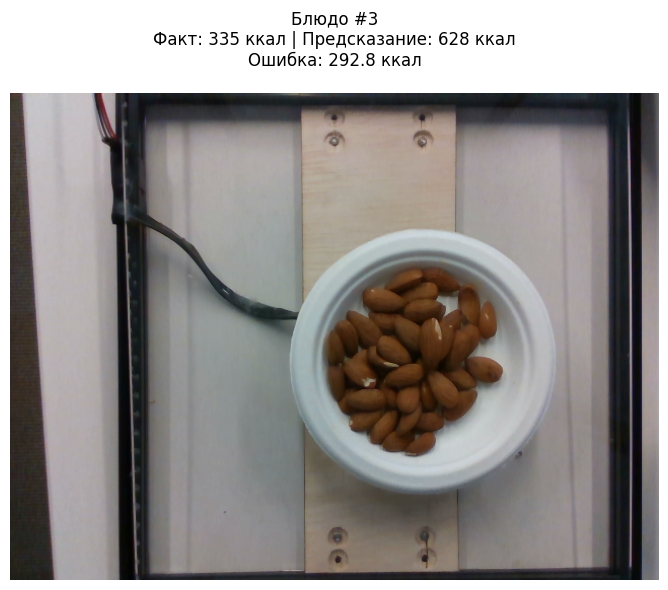


🔴 #4 | Ошибка: 252.8 ккал
   ID блюда: dish_1566328831
   🎯 Фактические калории: 942 ккал
   🤖 Предсказанные калории: 689 ккал
   ⚖️  Масса блюда: 500 г
   🥗 Ингредиенты: pizza, cherry tomatoes, chicken, pineapple, olives


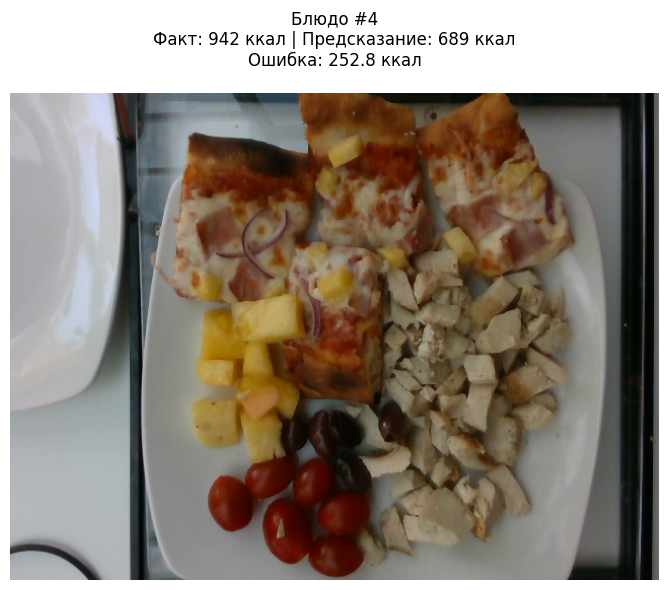


🔴 #5 | Ошибка: 243.9 ккал
   ID блюда: dish_1566328805
   🎯 Фактические калории: 928 ккал
   🤖 Предсказанные калории: 684 ккал
   ⚖️  Масса блюда: 488 г
   🥗 Ингредиенты: cherry tomatoes, pizza, chicken, pineapple


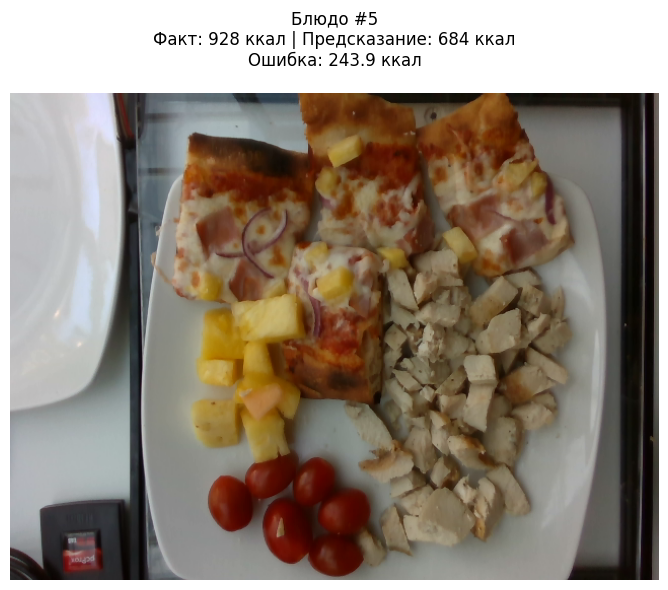


🎉 Анализ завершен!


In [15]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import sys

# путь к скриптам
sys.path.append('scripts')

from utils import MultimodalModel, validate_epoch, calculate_f1_score, collate_fn
from dataset import MultimodalDataset, get_transforms, prepare_data
from evaluation import display_top_errors, analyze_error_distribution
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

class Config:
    SEED = 42
    TEXT_MODEL_NAME = "bert-base-uncased"
    IMAGE_MODEL_NAME = "tf_efficientnet_b0"
    TEXT_MODEL_UNFREEZE = "encoder.layer.11|pooler"
    IMAGE_MODEL_UNFREEZE = "blocks.6|conv_head|bn2"
    BATCH_SIZE = 32
    TEXT_LR = 3e-5
    IMAGE_LR = 1e-4
    CLASSIFIER_LR = 1e-3
    DROPOUT = 0.3
    HIDDEN_DIM = 256
    DATA_PATH = "data"
    IMAGE_DIR = "data/images"
    SAVE_PATH = "best_model.pth"

def load_and_evaluate_best_model(cfg, device):
    """Загрузка лучшей модели и оценка на тестовых данных"""
    
    # загрузка данных
    train_dataset, test_dataset, num_ingredients = prepare_data(cfg)
    
    test_loader = torch.utils.data.DataLoader(
        test_dataset, 
        batch_size=cfg.BATCH_SIZE, 
        shuffle=False, 
        collate_fn=collate_fn
    )
    
    # загрузка модели
    model = MultimodalModel(num_ingredients, cfg).to(device)
    model.load_state_dict(torch.load(cfg.SAVE_PATH, map_location=device))
    model.eval()
    
    print("✅ Модель успешно загружена")
    
    # оценка модели
    criterion = nn.L1Loss()
    test_loss, test_mae, test_rmse, test_r2, test_f1, all_preds, all_targets = validate_epoch(
        model, test_loader, criterion, device, cfg
    )
    
    # финальные метрики
    print(f"\n{'='*60}")
    print("ФИНАЛЬНЫЕ МЕТРИКИ МОДЕЛИ")
    print(f"{'='*60}")
    print(f"📊 Test MAE:  {test_mae:.2f} ккал")
    print(f"📊 Test RMSE: {test_rmse:.2f} ккал")
    print(f"📊 Test R²:   {test_r2:.4f}")
    print(f"📊 Test F1:   {test_f1:.4f}")
    
    if test_mae < 50:
        print("🎯 ✅ Модель соответствует целевому показателю (MAE < 50)")
    else:
        print("🎯 ❌ Модель НЕ соответствует целевому показателю")
    
    return model, test_dataset, all_preds, all_targets

def normalize_ingredient_id(ingr_id):
    """Нормализация ID ингредиента - несколько стратегий поиска"""
    if pd.isna(ingr_id):
        return ingr_id
    
    ingr_id = str(ingr_id).strip()
    
    # убираем 'ingr_' префикс
    if ingr_id.startswith('ingr_'):
        simple_normalized = ingr_id[5:]  # Убираем 'ingr_'
        
        # убираем ведущие нули после префикса
        if simple_normalized.isdigit():
            digit_normalized = str(int(simple_normalized))
            return digit_normalized
        return simple_normalized
    
    return ingr_id

def get_ingredient_names(ingredient_ids, ingredients_df):
    """Получение названий ингредиентов по их ID с нормализацией"""
    if pd.isna(ingredient_ids) or ingredient_ids == '':
        return "Нет ингредиентов"
    
    ingr_list = ingredient_ids.split(';')
    ingr_names = []
    
    # создаем нормализованный словарь для быстрого поиска
    ingr_dict = {}
    for _, row in ingredients_df.iterrows():
        # преобразуем ID в строку и убираем лишние пробелы
        normalized_id = str(row['id']).strip()
        ingr_dict[normalized_id] = row['ingr']
    
    #print(f"🔍 Создан словарь с {len(ingr_dict)} ингредиентами")
    #print("Примеры из словаря:")
    #for i, (ingr_id, ingr_name) in enumerate(list(ingr_dict.items())[:5]):
        #print(f"  '{ingr_id}' -> '{ingr_name}'")
    
    for ingr_id in ingr_list:
        # нормализуем ID из dish.csv
        normalized_id = normalize_ingredient_id(ingr_id.strip())
        
        if normalized_id in ingr_dict:
            ingr_names.append(ingr_dict[normalized_id])
        else:
            # пробуем найти без нормализации
            if ingr_id in ingr_dict:
                ingr_names.append(ingr_dict[ingr_id])
            else:
                ingr_names.append(f"неизвестный ({ingr_id} -> {normalized_id})")
    
    return ", ".join(ingr_names)


# ЗАПУСК АНАЛИЗА
device = "cuda" if torch.cuda.is_available() else "cpu"
cfg = Config()

print("Загрузка и оценка лучшей модели...")
model, test_dataset, predictions, targets = load_and_evaluate_best_model(cfg, device)

# анализ распределения ошибок
analyze_error_distribution(predictions, targets)

# отображение блюд с наибольшими ошибками
display_top_errors(model, test_dataset, predictions, targets, cfg, top_k=5)

print(f"\n🎉 Анализ завершен!")

## ВЫВОДЫ:

ФИНАЛЬНЫЕ МЕТРИКИ МОДЕЛИ
============================================================

📊 Test MAE:  46.11 ккал  -- в среднем модель ошибается на 46 калорий на одно блюдо
📊 Test RMSE: 73.01 ккал -- RMSE>MAE - говорит о том, что есть выборосы с большими ошибками
📊 Test R²:   0.8811 -- модель "хорошо понимает" закономерности между ингредиентами, изображениями и калорийностью (0.7 уже считается, что хорошо)
📊 Test F1:   0.8095 - высокое качество предсказаний, пости 80% предсказаний имеют ошибку меньше 50 калорий
🎯 ✅ Модель соответствует целевому показателю (MAE < 50)

Максимальные ошибки: из примеров предположу, что в текущем виде модели сложно справиться с комплексными блюдами (как возможные улучшения здесь надо добавлять новые признаки, например, рецепты, и больше примеров с комплексными блюдами для дообучения); в случае с орехами, надо разбираться подбробно, здесь может быть ошибка (кажется, что слишком много калорий), но это как первая гипотеза для проверки.
